# Ejercicio práctico clase 3 - Grupo 6

In [39]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import Rectangle
import matplotlib.dates as mdates
from datetime import datetime
import warnings
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import plotly.express as px
import plotly.io as pio
import seaborn as sns
import plotly.graph_objects as go
import folium
import webbrowser
from folium.plugins import TimestampedGeoJson


#Carga de archivo CSV de Ciberseguridad

In [19]:
df = pd.read_csv('Dataset/cybersecurity.csv')

#Exploracion 

In [20]:
print("Dimensiones del dataset:", df.shape)
print("\nPrimeras 5 filas:")
df.head()

Dimensiones del dataset: (10000, 13)

Primeras 5 filas:


,timestamp,src_ip,dst_ip,src_port,dst_port,protocol,bytes_sent,bytes_received,user_agent,url,is_internal_traffic,label,attack_type
0,2025-10-01 00:12:54,188.176.27.165,253.240.113.218,56377,445,TCP,8029,17204,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,https://webmail.corp/login?id=385071,False,0,benign
1,2025-10-01 00:23:43,68.59.26.43,212.75.38.111,51165,1433,TCP,676368,2643374,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,https://portal.example.org/owa/auth/logon.aspx...,False,0,benign
2,2025-10-01 00:25:46,119.204.243.78,90.28.90.234,14948,1433,TCP,316502,38571,Mozilla/5.0 (Windows NT 10.0; Win64; x64; rv:1...,NaN,False,0,benign
3,2025-10-01 00:27:21,122.119.194.175,175.140.78.230,36097,443,TCP,70933,21935,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,https://webmail.corp/phpmyadmin?id=114701,False,0,benign
4,2025-10-01 00:40:09,181.199.242.68,55.99.177.69,445,21255,TCP,12721,9939,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,https://portal.example.org/config.php?id=345569,False,0,benign


#Limpieza y transformacion de datos

In [6]:
#df_clean = df.copy()

# df_clean['hora'] = df_clean['timestamp'].dt.hour #   Extrae la hora del día de la columna 'timestamp' y la almacena en una nueva columna 'hora'.
# df_clean['dia_semana'] = df_clean['timestamp'].dt.day_name()#  Extrae el nombre del día de la semana de la columna 'timestamp' y lo almacena en una nueva columna 'dia_semana'.
# df_clean['minuto_del_dia'] = df_clean['timestamp'].dt.hour * 60 + df_clean['timestamp'].dt.minute #Crea una nueva columna 'minuto_del_dia' que representa el minuto del día (0-1439) calculado a partir de la hora y el minuto.
# df_clean['fecha'] = df_clean['timestamp'].dt.date #Extrae la fecha sin la hora.
# df_clean['protocol'] = df_clean['protocol'].str.lower().str.strip() #Pasa todo a minúsculas y quita espacios en blanco innecesarios.

#  Desarrollo del Trabajo

## Seaborn

In [5]:
print(df.columns.tolist())

['timestamp', 'src_ip', 'dst_ip', 'src_port', 'dst_port', 'protocol', 'bytes_sent', 'bytes_received', 'user_agent', 'url', 'is_internal_traffic', 'label', 'attack_type']


####### IPs que generan mucho tráfico en ventanas cortas de tiempo, lo cual puede indicar: ataques de fuerza bruta, escaneo de puertos

In [8]:
df['timestamp'] = pd.to_datetime(df['timestamp'])

# bytes totales
df['bytes_total'] = df['bytes_sent'] + df['bytes_received']

# agrupar cada 5 minutos
df_group = (
    df.groupby(['src_ip', pd.Grouper(key='timestamp', freq='5min')])
    ['bytes_total']
    .sum()
    .reset_index()
)

# obtener top 10 IPs
top_ips = (
    df_group.groupby('src_ip')['bytes_total']
    .sum()
    .nlargest(10)
    .index
)

df_plot = df_group[df_group['src_ip'].isin(top_ips)]

# gráfico interactivo
fig = px.line(
    df_plot,
    x='timestamp',
    y='bytes_total',
    color='src_ip',
    title='ANÁLISIS DE FUERZA BRUTA - IPs con alto volumen de bytes',
    markers=True
)

fig.show()

In [ ]:
## 

In [11]:
fig = px.scatter(
    ua_activity,
    x='conexiones',
    y='bytes_total',
    color='user_agent',
    size='bytes_total',
    hover_data=['src_ip'],
    title='Relación entre conexiones y tráfico por User-Agent'
)

fig.show()

###usando user_agent + frecuencia de conexiones + volumen de tráfico. Esto ayuda a detectar bots, scraping.
Eje X (conexiones): número de solicitudes realizadas por un user_agent

Eje Y (bytes_totales): volumen total de datos transferidos

Tamaño del punto (ips_unicas): cuántas IP diferentes usan ese user_agent

Esto crea una “huella de comportamiento” para cada user_agent.

In [6]:
df['timestamp'] = pd.to_datetime(df['timestamp'])

# limpiar user_agent
df['user_agent'] = df['user_agent'].str.lower().str.strip()

# calcular bytes totales
df['bytes_total'] = df['bytes_sent'] + df['bytes_received']

# agrupar por user_agent
fingerprint = (
    df.groupby('user_agent')
    .agg(
        conexiones=('user_agent','count'),
        bytes_total=('bytes_total','sum'),
        ips_unicas=('src_ip','nunique')
    )
    .reset_index()
)

# quedarnos con los más activos
fingerprint = fingerprint.sort_values(
    'conexiones',
    ascending=False
).head(20)

# gráfico interactivo
fig = px.scatter(
    fingerprint,
    x='conexiones',
    y='bytes_total',
    size='ips_unicas',
    color='user_agent',
    hover_data=['ips_unicas'],
    title='Attack Fingerprint - comportamiento por User Agent'
)

fig.update_layout(
    xaxis_title="Número de conexiones",
    yaxis_title="Bytes totales transferidos",
    legend_title="User Agent"
)

fig.show()

###Mapa de ataque IP → destino, que permite ver qué IP origen está atacando a qué destino. Muestra patrones de ataque

In [7]:
df['timestamp'] = pd.to_datetime(df['timestamp'])

# calcular bytes totales
df['bytes_total'] = df['bytes_sent'] + df['bytes_received']

# agrupar tráfico entre IP origen y destino
mapa_ataques = (
    df.groupby(['src_ip','dst_ip'])
    .agg(
        conexiones=('src_ip','count'),
        bytes_total=('bytes_total','sum')
    )
    .reset_index()
)

# tomar los ataques más significativos
mapa_ataques = mapa_ataques.sort_values(
    'conexiones',
    ascending=False
).head(50)

# gráfico interactivo
fig = px.scatter(
    mapa_ataques,
    x='src_ip',
    y='dst_ip',
    size='conexiones',
    color='bytes_total',
    hover_data=['conexiones','bytes_total'],
    title='Mapa de ataques: IP origen → IP destino'
)

fig.update_layout(
    xaxis_title="IP origen (posible atacante)",
    yaxis_title="IP destino (objetivo)"
)

fig.show()

#  Seaborn
### detectar patrones de ataque: por hora y día de la semana, este gráfico nos permite ver rápidamente cuándo ocurre más actividad sospechosa.

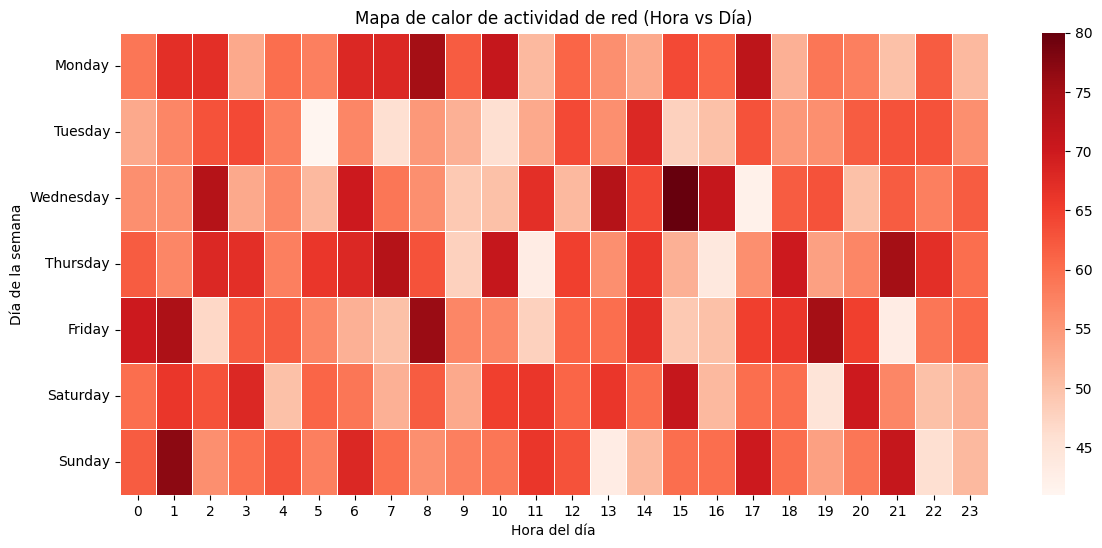

In [12]:
df['timestamp'] = pd.to_datetime(df['timestamp'])

# extraer hora y día
df['hora'] = df['timestamp'].dt.hour
df['dia_semana'] = df['timestamp'].dt.day_name()

# crear tabla pivote
heatmap_data = df.pivot_table(
    index='dia_semana',
    columns='hora',
    values='src_ip',
    aggfunc='count'
)

# ordenar días
orden_dias = [
    "Monday","Tuesday","Wednesday",
    "Thursday","Friday","Saturday","Sunday"
]

heatmap_data = heatmap_data.reindex(orden_dias)

# graficar
plt.figure(figsize=(14,6))

sns.heatmap(
    heatmap_data,
    cmap="Reds",
    linewidths=0.5
)

plt.title("Mapa de calor de actividad de red (Hora vs Día)")
plt.xlabel("Hora del día")
plt.ylabel("Día de la semana")

plt.show()

#  Plotly
### 

In [13]:
df['timestamp'] = pd.to_datetime(df['timestamp'])

df['bytes_total'] = df['bytes_sent'] + df['bytes_received']

protocol_stats = (
    df.groupby('protocol')
    .agg(
        conexiones=('protocol','count'),
        bytes_total=('bytes_total','sum')
    )
    .reset_index()
)

fig = px.bar(
    protocol_stats,
    x='protocol',
    y='conexiones',
    color='bytes_total',
    title='Distribución de tráfico por protocolo',
    hover_data=['bytes_total']
)

fig.show()

###IP origen → protocolo → IP destino

In [16]:
flow = (
    df.groupby(['src_ip','protocol','dst_ip'])
    .size()
    .reset_index(name='count')
)

flow = flow.sort_values('count',ascending=False).head(20)

labels = list(pd.concat([flow['src_ip'],flow['protocol'],flow['dst_ip']]).unique())

source = flow['src_ip'].apply(lambda x: labels.index(x))
target = flow['protocol'].apply(lambda x: labels.index(x))
value = flow['count']

fig = go.Figure(data=[go.Sankey(
    node=dict(label=labels),
    link=dict(source=source,target=target,value=value)
)])

fig.update_layout(title_text="Flujo de tráfico IP → Protocolo → Destino")

fig.show()

###picos de tráfico por hora

horas donde ocurre más actividad

posibles ventanas de ataque

In [23]:
df['bytes_total'] = df['bytes_sent'] + df['bytes_received']

In [28]:
df['timestamp'] = pd.to_datetime(df['timestamp'])
df['hora'] = df['timestamp'].dt.hour

traffic = (
    df.groupby('hora')
    .agg(
        conexiones=('src_ip','count'),
        bytes=('bytes_total','sum')
    )
    .reset_index()
)

fig = px.scatter(
    traffic,
    x='hora',
    y='bytes',
    size='conexiones',
    color='conexiones',
    title='Anomalías de tráfico por hora'
)

fig.show()

#   Folium

### visualizar la actividad de direcciones IP en un mapa mundial interactivo. Básicamente, toma un registro de eventos, cuenta cuáles son las IPs más frecuentes y las "dibuja" en un mapa.

In [41]:
# obtener IPs más activas
top_ips = (
    df.groupby('src_ip')
    .size()
    .reset_index(name='eventos')
    .sort_values('eventos', ascending=False)
    .head(20)
)

# crear mapa base
mapa = folium.Map(location=[0,0], zoom_start=2)

# agregar puntos
for _, row in top_ips.iterrows():

    lat = np.random.uniform(-60,60)
    lon = np.random.uniform(-180,180)

    folium.CircleMarker(
        location=[lat, lon],
        radius=max(5,row['eventos']/5),
        popup=f"IP: {row['src_ip']} | Eventos: {row['eventos']}",
        color="red",
        fill=True
    ).add_to(mapa)

# guardar mapa
archivo = "mapa_ataques.html"
mapa.save(archivo)

# abrir automáticamente en navegador
webbrowser.open(archivo)

True